# P1 · Predictions, targets, and loss

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.13 · Predictions, targets, and loss

Cross-entropy consumes raw logits and targets. Its average must count the valid supervised positions.

**Prerequisites:** Feed-forward blocks and residual paths

**Predict:** What should enter cross_entropy?

**Mental model:** A prediction contains one score for every candidate character. These raw scores are logits, and softmax converts them into probabilities for inspection or sampling.

### Why this operation exists

A prediction contains one score for every candidate character. These raw scores are logits, and softmax converts them into probabilities for inspection or sampling.

A target is the ID of the character that actually follows the context. Cross-entropy measures the negative log probability assigned to that target.

The library's cross-entropy operation accepts raw logits and performs its normalization stably. Applying softmax first changes the intended computation.

Padding or other intentionally ignored targets should contribute neither error nor an extra count to the average. Keep the denominator visible.

Accuracy asks whether the largest-score ID is correct. Loss also responds to the probability assigned to the correct ID, even when accuracy stays unchanged.

### Follow the values

The logits contain two examples, two time positions and three candidate IDs. The final axis is vocabulary, not time.

Softmax over that final axis creates a probability distribution for each position. These probabilities are displayed for understanding, not passed into cross-entropy.

Compute one loss per position. The ignored target produces zero in this unreduced output, while the three supervised positions each contribute their own loss.

Add the losses and divide by the valid count, three in the first experiment. Including the fourth target changes both the total and the count.

The predicted IDs match every supervised target in this illustration, so accuracy is exactly one. The positive loss still distinguishes these predictions from assigning probability one to every target.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
logits = torch.tensor([[[2.,1.,0.],[1.,2.,0.]],[[0.,1.,2.],[3.,0.,0.]]])
targets = torch.tensor([[0,1],[2,0 if change else -100]])
show("Logits [B,T,V]", logits)
show("Probabilities over vocabulary", logits.softmax(-1))
losses = F.cross_entropy(logits.reshape(-1,3), targets.reshape(-1), ignore_index=-100, reduction="none").reshape(2,2)
show("Per-position losses; ignored position is zero", losses)
valid = targets != -100
mean = losses.sum()/valid.sum()
show("Valid count and mean", {"count": valid.sum().item(), "mean loss": mean.item()})
show("Correct IDs divided by valid count", ((logits.argmax(-1) == targets) & valid).sum().float()/valid.sum())
torch.testing.assert_close(mean, F.cross_entropy(logits.reshape(-1,3),targets.reshape(-1),ignore_index=-100))

Logits [B,T,V]: [[[2.0, 1.0, 0.0], [1.0, 2.0, 0.0]], [[0.0, 1.0, 2.0], [3.0, 0.0, 0.0]]]
  shape [2, 2, 3] · torch.float32 · cpu
Probabilities over vocabulary: [[[0.6652409434318542, 0.2447284758090973, 0.09003057330846786], [0.2447284758090973, 0.6652409434318542, 0.09003057330846786]], [[0.09003057330846786, 0.2447284758090973, 0.6652409434318542], [0.9094430208206177, 0.04527850076556206, 0.04527850076556206]]]
  shape [2, 2, 3] · torch.float32 · cpu
Per-position losses; ignored position is zero: [[0.40760594606399536, 0.40760594606399536], [0.40760594606399536, 0.0]]
  shape [2, 2] · torch.float32 · cpu
Valid count and mean: {"count": 3, "mean loss": 0.40760597586631775}
Correct IDs divided by valid count: 1.0
  shape [] · torch.float32 · cpu


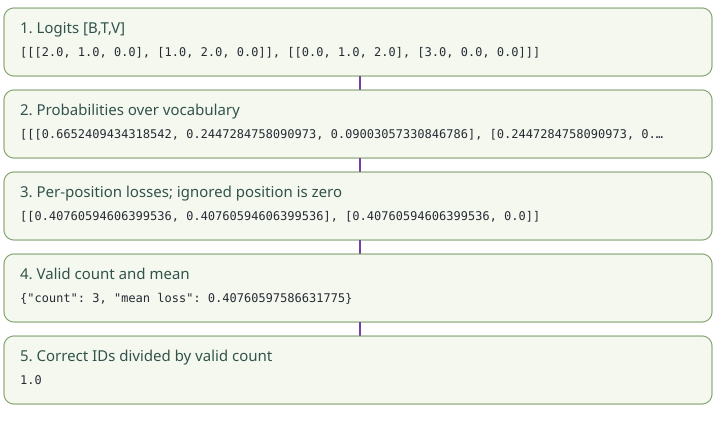

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

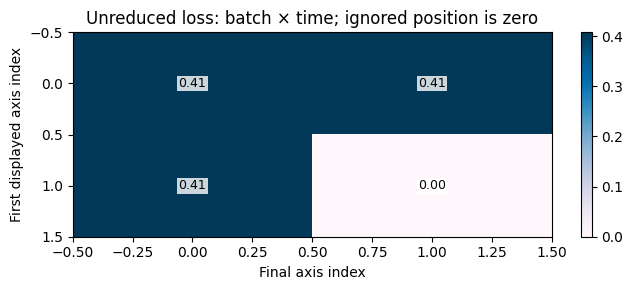

In [5]:
image = (losses).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Unreduced loss: batch × time; ignored position is zero'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

Reshape logits to a two-dimensional table of positions by candidates. Reshape targets to the matching one-dimensional sequence of target IDs.

Cross-entropy expects the candidate axis in its documented position. Flattening batch and time here makes that convention explicit.

Reduction none exposes individual losses. A Boolean validity mask supplies the denominator for the ordinary unweighted target-index mean used here.

Ignore index is a loss convention, not an instruction to remove a position from attention. The corresponding attention masking policy must be implemented separately.

An entirely ignored batch has no valid mean. Detect a zero valid count rather than reporting an invalid number as a meaningful training loss.

### Change one thing

**Include the fourth target**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
logits = torch.tensor([[[2.,1.,0.],[1.,2.,0.]],[[0.,1.,2.],[3.,0.,0.]]])
targets = torch.tensor([[0,1],[2,0 if change else -100]])
show("Logits [B,T,V]", logits)
show("Probabilities over vocabulary", logits.softmax(-1))
losses = F.cross_entropy(logits.reshape(-1,3), targets.reshape(-1), ignore_index=-100, reduction="none").reshape(2,2)
show("Per-position losses; ignored position is zero", losses)
valid = targets != -100
mean = losses.sum()/valid.sum()
show("Valid count and mean", {"count": valid.sum().item(), "mean loss": mean.item()})
show("Correct IDs divided by valid count", ((logits.argmax(-1) == targets) & valid).sum().float()/valid.sum())
torch.testing.assert_close(mean, F.cross_entropy(logits.reshape(-1,3),targets.reshape(-1),ignore_index=-100))

Logits [B,T,V]: [[[2.0, 1.0, 0.0], [1.0, 2.0, 0.0]], [[0.0, 1.0, 2.0], [3.0, 0.0, 0.0]]]
  shape [2, 2, 3] · torch.float32 · cpu
Probabilities over vocabulary: [[[0.6652409434318542, 0.2447284758090973, 0.09003057330846786], [0.2447284758090973, 0.6652409434318542, 0.09003057330846786]], [[0.09003057330846786, 0.2447284758090973, 0.6652409434318542], [0.9094430208206177, 0.04527850076556206, 0.04527850076556206]]]
  shape [2, 2, 3] · torch.float32 · cpu
Per-position losses; ignored position is zero: [[0.40760594606399536, 0.40760594606399536], [0.40760594606399536, 0.09492291510105133]]
  shape [2, 2] · torch.float32 · cpu
Valid count and mean: {"count": 4, "mean loss": 0.32943519949913025}


Correct IDs divided by valid count: 1.0
  shape [] · torch.float32 · cpu


### A useful distinction

ignore_index affects loss contributions. It does not automatically create an attention mask.

### ✋ Your turn

For losses [2,4,0] with only the first two positions valid, put the valid-position mean in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'ignore_index affects loss contributions. It does not automatically create an attention mask.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
losses = torch.tensor([2.,4.,0.])
valid = torch.tensor([True,True,False])
answer = (losses.sum()/valid.sum()).item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 3, 'ignore_index affects loss contributions. It does not automatically create an attention mask.'
    print("✓ right:", answer)

✓ right: 3.0


### Reconnect to the transformer

The current model compares every input position's logits with its next-character target. Its fixed-length character windows do not need padded targets.

Phyll uses a padding ID that its loss ignores. The ID is specific to that tokenizer; zero is not universally padding in every model.

The library averages over valid target positions for the unweighted class-index case. Other loss weighting options can use a different normalization.

The training unit explains stable cross-entropy, dataset aggregation and the difference between fitting training data and improving validation performance.

Next, ask how this scalar loss supplies information to every parameter used in its computation.

```python
loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What should enter cross_entropy?

<details><summary>Check your explanation</summary>

Raw logits. ignore_index affects loss contributions. It does not automatically create an attention mask.

</details>